In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data source: BTS T-100 Domestic Market data
# https://www.bts.gov/browse-statistical-products-and-data/bts-publications/%E2%80%A2-data-bank-28is-t-100-and-t-100f

In [88]:
# 28 column names matching the BTS DB28 data dictionary
col_names = [
    'YEAR',                      # e.g. 2025
    'MONTH',                     # e.g. 03
    'ORIGIN_AIRPORT_CODE',       # IATA/DOT alpha code (e.g. FL)
    'ORIGIN_AIRPORT_ID',         # 5-digit origin city code
    'ORIGIN_WAC',                # World Area Code for Origin
    'ORIGIN_CITY_NAME',          # City, State/Country
    'DEST_AIRPORT_CODE',         # IATA/DOT alpha code (e.g. PSM)
    'DEST_AIRPORT_ID',           # 5-digit dest city code
    'DEST_WAC',                  # World Area Code for Destination
    'DEST_CITY_NAME',            # City, State/Country
    'CARRIER_CODE',              # Carrier alpha code (e.g. ADB)
    'CARRIER_ENTITY_CODE',       # Carrier numeric/entity code
    'OAI_GROUP_CODE',            # Official OAI group classification
    'DISTANCE_MILES',            # Great-circle distance, statute miles
    'SERVICE_CLASS',             # F, G, L, P, etc.
    'AIRCRAFT_TYPE_GROUP',       # General category code
    'AIRCRAFT_TYPE',             # Specific aircraft code
    'AIRCRAFT_CONFIG',           # 1=passenger, 2=cargo, etc.
    'DEPARTURES_PERFORMED',      # Actual revenue departures
    'DEPARTURES_SCHEDULED',      # Scheduled departures
    'AVAILABLE_PAYLOAD_LBS',     # Payload capacity, pounds
    'AVAILABLE_SEATS',           # Seats available
    'PASSENGERS_TRANSPORTED',    # Total passengers carried
    'FREIGHT_LBS',               # Freight carried, pounds
    'MAIL_LBS',                  # Mail carried, pounds
    'RAMP_TO_RAMP_TIME_MINS',    # Total block time, minutes
    'AIRBORNE_TIME_MINS',        # Airborne time, minutes
    'CARRIER_WAC'                # Carrier’s World Area Code
]

file_path = 'db28seg.fd.wac.202404.202503.asc'

# Read raw, pipe-delimited file
df = pd.read_csv(file_path, sep='|', header=None)

# If there's a trailing empty column from the final '|', drop it
if df.shape[1] == len(col_names) + 1:
    df = df.iloc[:, :-1]

# Assign our human-friendly names
df.columns = col_names

print("Successfully loaded data; here are the columns:")
print(df.columns.tolist())

# Peek at the first few rows
df.head()



Successfully loaded data; here are the columns:
['YEAR', 'MONTH', 'ORIGIN_AIRPORT_CODE', 'ORIGIN_AIRPORT_ID', 'ORIGIN_WAC', 'ORIGIN_CITY_NAME', 'DEST_AIRPORT_CODE', 'DEST_AIRPORT_ID', 'DEST_WAC', 'DEST_CITY_NAME', 'CARRIER_CODE', 'CARRIER_ENTITY_CODE', 'OAI_GROUP_CODE', 'DISTANCE_MILES', 'SERVICE_CLASS', 'AIRCRAFT_TYPE_GROUP', 'AIRCRAFT_TYPE', 'AIRCRAFT_CONFIG', 'DEPARTURES_PERFORMED', 'DEPARTURES_SCHEDULED', 'AVAILABLE_PAYLOAD_LBS', 'AVAILABLE_SEATS', 'PASSENGERS_TRANSPORTED', 'FREIGHT_LBS', 'MAIL_LBS', 'RAMP_TO_RAMP_TIME_MINS', 'AIRBORNE_TIME_MINS', 'CARRIER_WAC']


,YEAR,MONTH,ORIGIN_AIRPORT_CODE,ORIGIN_AIRPORT_ID,ORIGIN_WAC,ORIGIN_CITY_NAME,DEST_AIRPORT_CODE,DEST_AIRPORT_ID,DEST_WAC,DEST_CITY_NAME,...,DEPARTURES_PERFORMED,DEPARTURES_SCHEDULED,AVAILABLE_PAYLOAD_LBS,AVAILABLE_SEATS,PASSENGERS_TRANSPORTED,FREIGHT_LBS,MAIL_LBS,RAMP_TO_RAMP_TIME_MINS,AIRBORNE_TIME_MINS,CARRIER_WAC
0,2025,1,1FL,35221,33,"Titusville, FL",PSM,34259,14,"Portsmouth, NH",...,1,0,264000,0,0,88128,0,0,0,488
1,2025,3,2FL,36801,33,"West Palm Beach, FL",ELH,31534,204,"North Eleuthera, The Bahamas",...,1,0,3450,8,5,0,0,66,54,10
2,2024,12,2FL,36801,33,"West Palm Beach, FL",FPO,31731,204,"Freeport, The Bahamas",...,1,0,3450,8,2,0,0,54,30,10
3,2025,3,2FL,36801,33,"West Palm Beach, FL",MHH,33289,204,"Marsh Harbour, The Bahamas",...,1,0,3450,8,1,0,0,60,48,10
4,2025,3,2FL,36801,33,"West Palm Beach, FL",NAS,33605,204,"Nassau, The Bahamas",...,1,0,3450,8,4,0,0,72,54,10


In [89]:
ua_sf_tpe_bidir = df[
    (df['ORIGIN_AIRPORT_CODE'].isin(['SFO','TPE'])) &
    (df['DEST_AIRPORT_CODE'].isin(['SFO','TPE'])) &
    (df['CARRIER_CODE'] == 'UA')
]


# Inspect the result
print(f"Found {len(ua_sf_tpe_bidir)} monthly segment-records:")
ua_sf_tpe_bidir.head()

Found 44 monthly segment-records:


,YEAR,MONTH,ORIGIN_AIRPORT_CODE,ORIGIN_AIRPORT_ID,ORIGIN_WAC,ORIGIN_CITY_NAME,DEST_AIRPORT_CODE,DEST_AIRPORT_ID,DEST_WAC,DEST_CITY_NAME,...,DEPARTURES_PERFORMED,DEPARTURES_SCHEDULED,AVAILABLE_PAYLOAD_LBS,AVAILABLE_SEATS,PASSENGERS_TRANSPORTED,FREIGHT_LBS,MAIL_LBS,RAMP_TO_RAMP_TIME_MINS,AIRBORNE_TIME_MINS,CARRIER_WAC
91670,2025,1,SFO,32457,91,"San Francisco, CA",TPE,35306,781,"Taipei, Taiwan",...,17,17,1217358,4692,3934,58310,13593,14396,13776,10
91671,2025,1,SFO,32457,91,"San Francisco, CA",TPE,35306,781,"Taipei, Taiwan",...,37,37,4053251,12950,11239,306584,16814,30964,29630,10
91677,2025,2,SFO,32457,91,"San Francisco, CA",TPE,35306,781,"Taipei, Taiwan",...,21,21,1437431,5796,4509,98293,16643,17823,16978,10
91678,2025,2,SFO,32457,91,"San Francisco, CA",TPE,35306,781,"Taipei, Taiwan",...,28,28,3163377,9800,7877,435700,8323,23220,22338,10
91683,2025,3,SFO,32457,91,"San Francisco, CA",TPE,35306,781,"Taipei, Taiwan",...,31,31,2106131,8556,6387,114736,21362,26255,25024,10


In [90]:
ua_sf_tpe_bidir[[
    'YEAR',                      # e.g. 2025
    'MONTH',                     # e.g. 03
    'ORIGIN_AIRPORT_CODE',       # IATA/DOT alpha code (e.g. FL)
    # 'ORIGIN_AIRPORT_ID',         # 5-digit origin city code
    # 'ORIGIN_WAC',                # World Area Code for Origin
    # 'ORIGIN_CITY_NAME',          # City, State/Country
    'DEST_AIRPORT_CODE',         # IATA/DOT alpha code (e.g. PSM)
    # 'DEST_AIRPORT_ID',           # 5-digit dest city code
    # 'DEST_WAC',                  # World Area Code for Destination
    # 'DEST_CITY_NAME',            # City, State/Country
    'CARRIER_CODE',              # Carrier alpha code (e.g. ADB)
    # 'CARRIER_ENTITY_CODE',       # Carrier numeric/entity code
    # 'OAI_GROUP_CODE',            # Official OAI group classification
    # 'DISTANCE_MILES',            # Great-circle distance, statute miles
    # 'SERVICE_CLASS',             # F, G, L, P, etc.
    # 'AIRCRAFT_TYPE_GROUP',       # General category code
    # 'AIRCRAFT_TYPE',             # Specific aircraft code
    # 'AIRCRAFT_CONFIG',           # 1=passenger, 2=cargo, etc.
    'DEPARTURES_PERFORMED',      # Actual revenue departures
    'DEPARTURES_SCHEDULED',      # Scheduled departures
    'AVAILABLE_PAYLOAD_LBS',     # Payload capacity, pounds
    'AVAILABLE_SEATS',           # Seats available
    'PASSENGERS_TRANSPORTED',    # Total passengers carried
    'FREIGHT_LBS',               # Freight carried, pounds
    'MAIL_LBS',                  # Mail carried, pounds
    'RAMP_TO_RAMP_TIME_MINS',    # Total block time, minutes
    'AIRBORNE_TIME_MINS',        # Airborne time, minutes
    'CARRIER_WAC'                # Carrier’s World Area Code
]]

,YEAR,MONTH,ORIGIN_AIRPORT_CODE,DEST_AIRPORT_CODE,CARRIER_CODE,DEPARTURES_PERFORMED,DEPARTURES_SCHEDULED,AVAILABLE_PAYLOAD_LBS,AVAILABLE_SEATS,PASSENGERS_TRANSPORTED,FREIGHT_LBS,MAIL_LBS,RAMP_TO_RAMP_TIME_MINS,AIRBORNE_TIME_MINS,CARRIER_WAC
91670,2025,1,SFO,TPE,UA,17,17,1217358,4692,3934,58310,13593,14396,13776,10
91671,2025,1,SFO,TPE,UA,37,37,4053251,12950,11239,306584,16814,30964,29630,10
91677,2025,2,SFO,TPE,UA,21,21,1437431,5796,4509,98293,16643,17823,16978,10
91678,2025,2,SFO,TPE,UA,28,28,3163377,9800,7877,435700,8323,23220,22338,10
91683,2025,3,SFO,TPE,UA,31,31,2106131,8556,6387,114736,21362,26255,25024,10
91684,2025,3,SFO,TPE,UA,31,31,3490152,10850,8505,364779,7961,26042,24931,10
91690,2024,4,SFO,TPE,UA,30,30,2024426,8280,5598,129726,24715,24851,23582,10
91691,2024,4,SFO,TPE,UA,30,30,3596380,10500,7723,338562,6578,24549,23413,10
91698,2024,5,SFO,TPE,UA,30,30,2083967,8280,7205,138535,20011,24511,23255,10
91699,2024,5,SFO,TPE,UA,32,32,3610774,11200,10102,806188,9698,25781,24589,10


In [84]:
# Define routes
routes = [('SFO', 'TPE'), ('TPE', 'SFO')]

# Initialize results list
results = []

# Group by year and month
for (year, month), group in df.groupby(['YEAR', 'MONTH']):
    for origin, dest in routes:
        # Filter data for the route
        subset = group[(group['ORIGIN_AIRPORT_CODE'] == origin) & 
                       (group['DEST_AIRPORT_CODE'] == dest) & 
                       (group['CARRIER_CODE'] == 'UA')]
        
        # Sum relevant columns
        departures = subset['DEPARTURES_PERFORMED'].sum()
        passengers = subset['PASSENGERS_TRANSPORTED'].sum()
        seats = subset['AVAILABLE_SEATS'].sum()
        
        # Calculate load factor
        load_factor = (passengers / seats * 100) if seats > 0 else 0
        
        # Format month-year
        month_year = f"{year}-{month:02d}"
        
        # Append to results
        results.append({
            'Month-Year': month_year,
            'Route': f"{origin}-{dest}",
            'Departures Performed': departures,
            'Passengers Transported': passengers,
            'Available Seats': seats,
            'Load Factor (%)': round(load_factor, 1)
        })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Sort by Month-Year and Route for better readability
results_df = results_df.sort_values(by=['Month-Year', 'Route'])
results_df

,Month-Year,Route,Departures Performed,Passengers Transported,Available Seats,Load Factor (%)
0,2024-04,SFO-TPE,60,13321,18780,70.9
1,2024-04,TPE-SFO,60,16774,18854,89.0
2,2024-05,SFO-TPE,62,17307,19480,88.8
3,2024-05,TPE-SFO,62,14092,19480,72.3
4,2024-06,SFO-TPE,60,17766,18780,94.6
5,2024-06,TPE-SFO,60,16114,18780,85.8
6,2024-07,SFO-TPE,60,15368,18780,81.8
7,2024-07,TPE-SFO,60,17919,18780,95.4
8,2024-08,SFO-TPE,62,13015,19332,67.3
9,2024-08,TPE-SFO,62,17908,19332,92.6


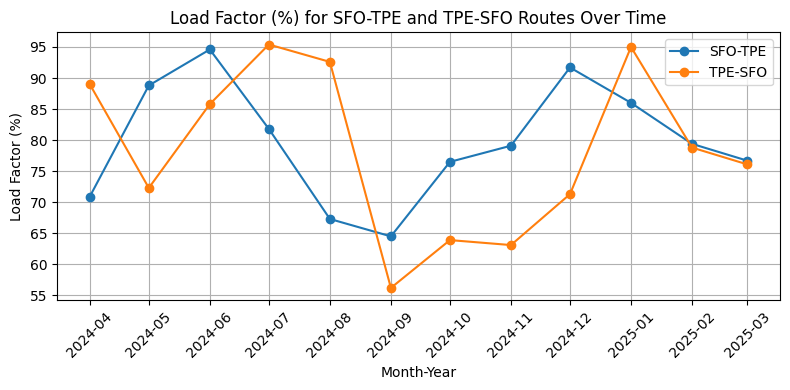

In [95]:
# Convert Month-Year to datetime for proper sorting
results_df['Month-Year'] = pd.to_datetime(results_df['Month-Year'], format='%Y-%m')
results_df = results_df.sort_values(by=['Month-Year', 'Route'])

# Pivot data for plotting
pivot_df = results_df.pivot(index='Month-Year', columns='Route', values='Load Factor (%)')

# Create line plot
plt.figure(figsize=(8, 4))
for route in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[route], marker='o', label=route)

# Customize plot
plt.title('Load Factor (%) for SFO-TPE and TPE-SFO Routes Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Load Factor (%)')
plt.legend()
plt.grid(True)

# Set x-ticks to show every month from the data
plt.xticks(ticks=pivot_df.index, rotation=45)

# Format x-axis to show Month-Year
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display plot
plt.show()
